In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision.datasets import ImageFolder
import torchvision.models as models

In [3]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [5]:
train_full = torchvision.datasets.CIFAR10(
    root='/kaggle/input/datasets/karemsaeed/cifar-10-batches-py', train=True, download=False, transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='/kaggle/input/datasets/karemsaeed/cifar-10-batches-py', train=False, download=False, transform=test_transform
)

In [6]:
print("Total samples:", len(train_full) + len(test_dataset))
print("Train samples:", len(train_full))
print("Test samples:", len(test_dataset))
print("Number of classes:", len(train_full.classes))
print("Classes:", train_full.classes)

sample_img, _ = train_full[0]
print("Image shape:", sample_img.shape)

Total samples: 60000
Train samples: 50000
Test samples: 10000
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: torch.Size([3, 224, 224])


In [7]:
indices = list(range(len(train_full)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset = Subset(train_full, train_idx)
val_dataset = Subset(train_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


In [10]:
def validate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

Epoch 1 | Loss: 0.4982 | Val Acc: 0.9049
Epoch 2 | Loss: 0.3043 | Val Acc: 0.9075
Epoch 3 | Loss: 0.2524 | Val Acc: 0.9236
Epoch 4 | Loss: 0.2171 | Val Acc: 0.9119
Epoch 5 | Loss: 0.1901 | Val Acc: 0.9227
Epoch 6 | Loss: 0.1688 | Val Acc: 0.9334
Epoch 7 | Loss: 0.1489 | Val Acc: 0.9328
Epoch 8 | Loss: 0.1370 | Val Acc: 0.9332
Epoch 9 | Loss: 0.1237 | Val Acc: 0.9362
Epoch 10 | Loss: 0.1144 | Val Acc: 0.9347


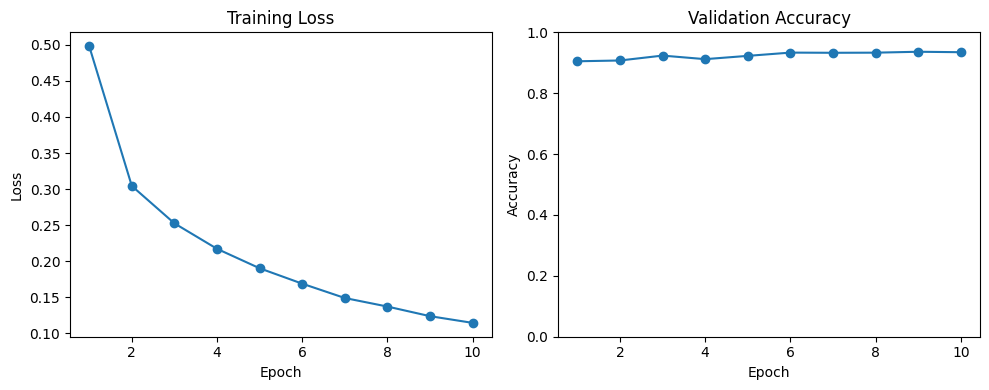

In [11]:
epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    val_acc = validate(model, val_loader)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_accuracies, marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [12]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

y_true_dl, y_pred_dl = evaluate_model(model, test_loader)

In [13]:
print("\n=== DL MODEL RESULTS ===")
accuracy_dl = accuracy_score(y_true_dl, y_pred_dl)
precision_dl = precision_score(y_true_dl, y_pred_dl, average='weighted')
recall_dl = recall_score(y_true_dl, y_pred_dl, average='weighted')
f1_dl = f1_score(y_true_dl, y_pred_dl, average='weighted')

print("Accuracy:", accuracy_dl)
print("Precision:", precision_dl)
print("Recall:", recall_dl)
print("F1-score:", f1_dl)

print(classification_report(y_true_dl, y_pred_dl))


=== DL MODEL RESULTS ===
Accuracy: 0.9333
Precision: 0.9340908046112487
Recall: 0.9333
F1-score: 0.9332443957202913
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1000
           1       0.91      0.99      0.94      1000
           2       0.90      0.95      0.92      1000
           3       0.88      0.87      0.87      1000
           4       0.94      0.95      0.94      1000
           5       0.92      0.88      0.90      1000
           6       0.96      0.95      0.96      1000
           7       0.97      0.94      0.96      1000
           8       0.96      0.95      0.96      1000
           9       0.97      0.91      0.94      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



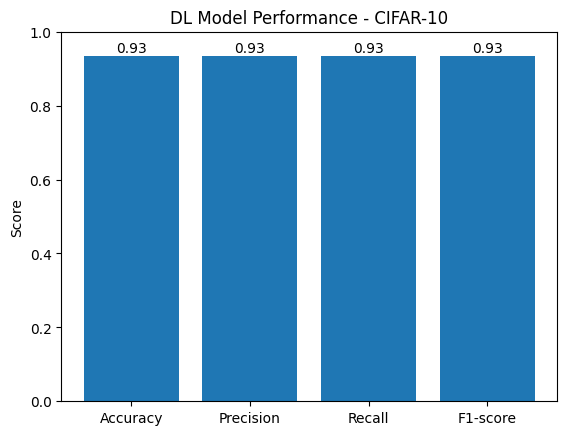

In [14]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [accuracy_dl, precision_dl, recall_dl, f1_dl]

plt.figure()
plt.bar(metrics, values)

plt.title("DL Model Performance - CIFAR-10")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

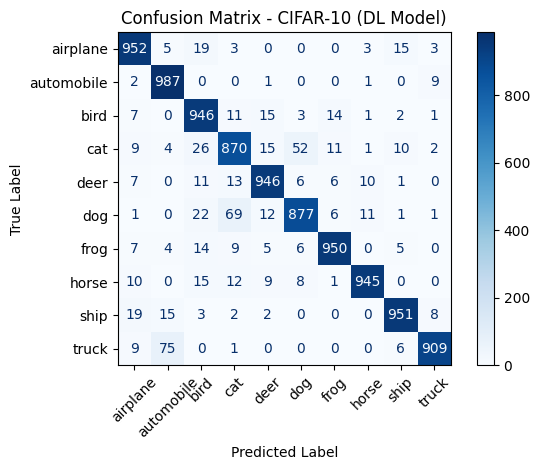

In [15]:
# CIFAR-10 class names (standard order)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

cm_dl = confusion_matrix(y_true_dl, y_pred_dl)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - CIFAR-10 (DL Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [16]:
feature_extractor = models.efficientnet_b0(pretrained=True)
feature_extractor.classifier[1] = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

def extract_features(loader):
    features, labels_list = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1)

            features.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.vstack(features), np.hstack(labels_list)

X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train, y_train)

y_pred_ml = svm.predict(X_test)

In [18]:
print("\n=== SVM MODEL RESULTS ===")
accuracy_svm = accuracy_score(y_test, y_pred_ml)
precision_svm = precision_score(y_test, y_pred_ml, average='weighted')
recall_svm = recall_score(y_test, y_pred_ml, average='weighted')
f1_svm = f1_score(y_test, y_pred_ml, average='weighted')

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

print(classification_report(y_test, y_pred_ml))


=== SVM MODEL RESULTS ===
Accuracy: 0.8333
Precision: 0.8345034862182172
Recall: 0.8333
F1-score: 0.8332071860463155
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1000
           1       0.88      0.92      0.90      1000
           2       0.77      0.83      0.79      1000
           3       0.71      0.72      0.72      1000
           4       0.84      0.73      0.78      1000
           5       0.78      0.78      0.78      1000
           6       0.87      0.88      0.88      1000
           7       0.88      0.85      0.87      1000
           8       0.91      0.88      0.90      1000
           9       0.90      0.87      0.88      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



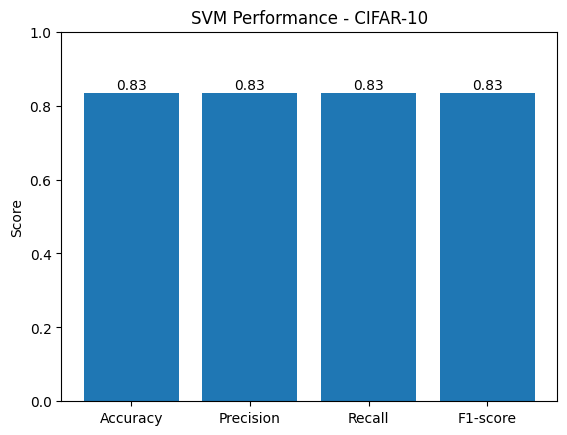

In [19]:
values = [accuracy_svm, precision_svm, recall_svm, f1_svm]

plt.figure()
plt.bar(metrics, values)

plt.title("SVM Performance - CIFAR-10")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

<Figure size 1000x800 with 0 Axes>

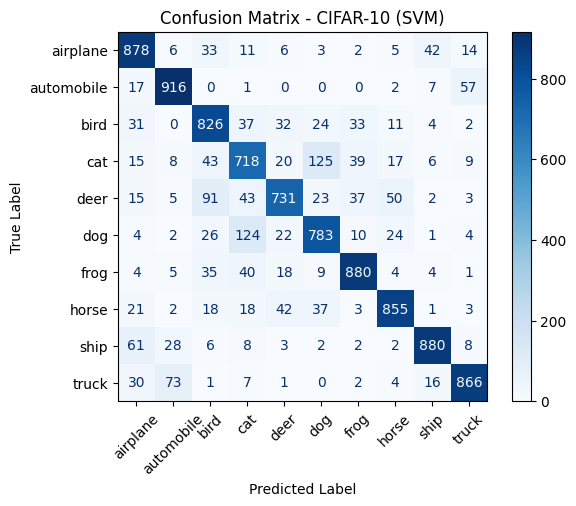

In [20]:
cm_svm = confusion_matrix(y_test, y_pred_ml)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - CIFAR-10 (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

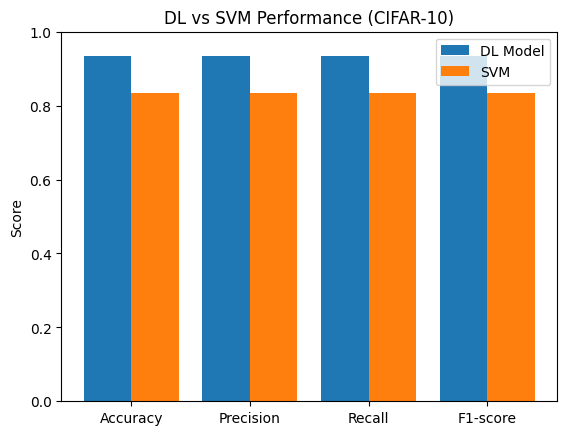

In [21]:
dl_values = [accuracy_dl, precision_dl, recall_dl, f1_dl]
svm_values = [accuracy_svm, precision_svm, recall_svm, f1_svm]

x = range(len(metrics))

plt.figure()

plt.bar(x, dl_values, width=0.4, label='DL Model')
plt.bar([i + 0.4 for i in x], svm_values, width=0.4, label='SVM')

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylim(0, 1)
plt.title("DL vs SVM Performance (CIFAR-10)")
plt.ylabel("Score")
plt.legend()

plt.show()

In [22]:
print("\n==============================")
print("BRAIN TUMOR MRI DATASET")
print("==============================")

train_full_mri = ImageFolder(
    root="/kaggle/input/datasets/karemsaeed/brain-tumor-mri-dataset/brain_tumor_mri_dataset/Training", transform=train_transform)
test_dataset_mri = ImageFolder(
    root="/kaggle/input/datasets/karemsaeed/brain-tumor-mri-dataset/brain_tumor_mri_dataset/Testing", transform=test_transform)

print("Train samples:", len(train_full_mri))
print("Test samples:", len(test_dataset_mri))
print("Classes:", train_full_mri.classes)


BRAIN TUMOR MRI DATASET
Train samples: 5600
Test samples: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [23]:
indices = list(range(len(train_full_mri)))
train_idx_mri, val_idx_mri = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset_mri = Subset(train_full_mri, train_idx_mri)
val_dataset_mri = Subset(train_full_mri, val_idx_mri)

train_loader_mri = DataLoader(train_dataset_mri, batch_size=32, shuffle=True)
val_loader_mri = DataLoader(val_dataset_mri, batch_size=32)
test_loader_mri = DataLoader(test_dataset_mri, batch_size=32)

In [24]:
model_mri = torchvision.models.efficientnet_b0(pretrained=True)
num_classes_mri = len(train_full_mri.classes)
model_mri.classifier[1] = nn.Linear(model_mri.classifier[1].in_features, num_classes_mri)
model_mri = model_mri.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mri.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[MRI] Epoch 1 | Loss: 0.3139 | Val Acc: 0.9705
[MRI] Epoch 2 | Loss: 0.1499 | Val Acc: 0.9732
[MRI] Epoch 3 | Loss: 0.0990 | Val Acc: 0.9563
[MRI] Epoch 4 | Loss: 0.0900 | Val Acc: 0.9625
[MRI] Epoch 5 | Loss: 0.0703 | Val Acc: 0.9625
[MRI] Epoch 6 | Loss: 0.0613 | Val Acc: 0.9625
[MRI] Epoch 7 | Loss: 0.0740 | Val Acc: 0.9866
[MRI] Epoch 8 | Loss: 0.0331 | Val Acc: 0.9732
[MRI] Epoch 9 | Loss: 0.0477 | Val Acc: 0.9821
[MRI] Epoch 10 | Loss: 0.0394 | Val Acc: 0.9786


ValueError: x and y must have same first dimension, but have shapes (10,) and (20,)

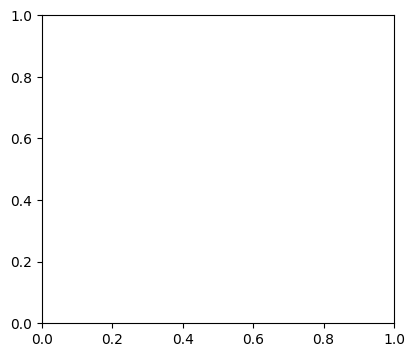

In [25]:
for epoch in range(epochs):
    model_mri.train()
    total_loss = 0

    for images, labels in train_loader_mri:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_mri(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_mri)
    train_losses.append(avg_loss)
    
    val_acc = validate(model_mri, val_loader_mri)
    val_accuracies.append(val_acc)
    print(f"[MRI] Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.title("Training Loss - MRI")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_accuracies, marker='o')
plt.title("Validation Accuracy - MRI")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [27]:
y_true_dl_mri, y_pred_dl_mri = evaluate_model(model_mri, test_loader_mri)

print("\n=== MRI DL RESULTS ===")

accuracy_dl_mri = accuracy_score(y_true_dl_mri, y_pred_dl_mri)
precision_dl_mri = precision_score(y_true_dl_mri, y_pred_dl_mri, average='weighted')
recall_dl_mri = recall_score(y_true_dl_mri, y_pred_dl_mri, average='weighted')
f1_dl_mri = f1_score(y_true_dl_mri, y_pred_dl_mri, average='weighted')

print(classification_report(y_true_dl_mri, y_pred_dl_mri))
print("Accuracy:", accuracy_dl_mri)
print("Precision:", precision_dl_mri)
print("Recall:", recall_dl_mri)
print("F1-score:", f1_dl_mri)


=== MRI DL RESULTS ===
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       400
           1       0.90      0.96      0.93       400
           2       0.92      1.00      0.96       400
           3       0.97      1.00      0.98       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600

Accuracy: 0.941875
Precision: 0.9454132346589303
Recall: 0.941875
F1-score: 0.9404116850378733


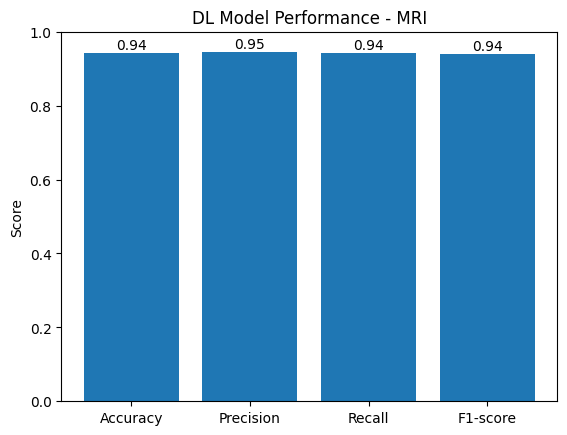

In [28]:
values = [accuracy_dl_mri, precision_dl_mri, recall_dl_mri, f1_dl_mri]

plt.figure()
plt.bar(metrics, values)

plt.title("DL Model Performance - MRI")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

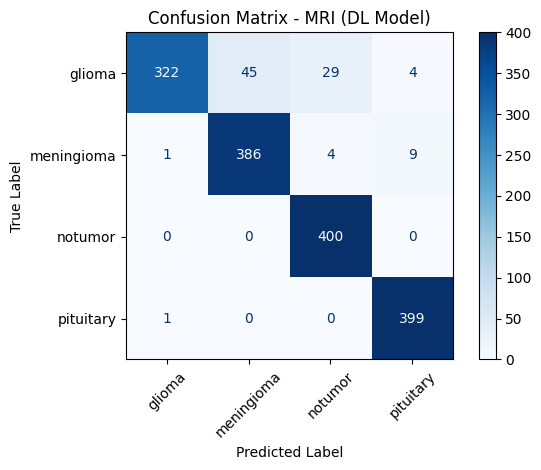

In [29]:
cm_dl_mri = confusion_matrix(y_true_dl_mri, y_pred_dl_mri)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl_mri,
    display_labels=train_full_mri.classes
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - MRI (DL Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [30]:
feature_extractor_mri = torchvision.models.efficientnet_b0(pretrained=True)
feature_extractor_mri.classifier[1] = nn.Identity()
feature_extractor_mri = feature_extractor_mri.to(device)
feature_extractor_mri.eval()

def extract_features_mri(loader):
    features, labels_list = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = feature_extractor_mri(images)
            outputs = outputs.view(outputs.size(0), -1)

            features.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.vstack(features), np.hstack(labels_list)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
X_train_mri, y_train_mri = extract_features_mri(train_loader_mri)
X_test_mri, y_test_mri = extract_features_mri(test_loader_mri)

svm_mri = SVC(kernel='linear', C=1.0)
svm_mri.fit(X_train_mri, y_train_mri)

y_pred_ml_mri = svm_mri.predict(X_test_mri)

In [34]:
print("\n=== MRI SVM RESULTS ===")
print(classification_report(y_test_mri, y_pred_ml_mri))

accuracy_svm_mri = accuracy_score(y_test_mri, y_pred_ml_mri)
precision_svm_mri = precision_score(y_test_mri, y_pred_ml_mri,average='weighted')
recall_svm_mri = recall_score(y_test_mri, y_pred_ml_mri, average='weighted')
f1_svm_mri = f1_score(y_test_mri, y_pred_ml_mri, average='weighted')

print("Accuracy:", accuracy_svm_mri)
print("Precision:", precision_svm_mri)
print("Recall:", recall_svm_mri)
print("F1-score:", f1_svm_mri)


=== MRI SVM RESULTS ===
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       400
           1       0.82      0.90      0.86       400
           2       0.92      1.00      0.95       400
           3       0.97      0.97      0.97       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600

Accuracy: 0.901875
Precision: 0.9044554380214173
Recall: 0.901875
F1-score: 0.8999080024649346


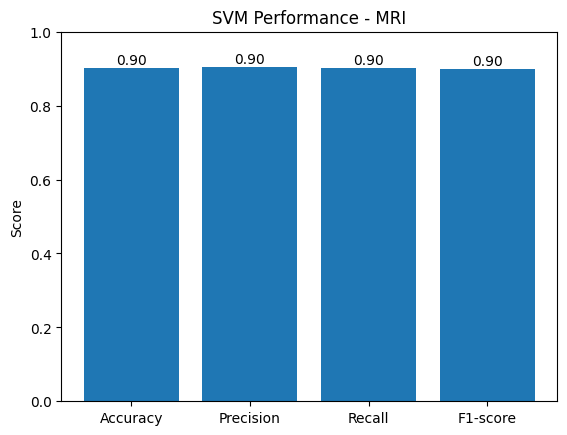

In [35]:
values = [accuracy_svm_mri, precision_svm_mri, recall_svm_mri, f1_svm_mri]

plt.figure()
plt.bar(metrics, values)

plt.title("SVM Performance - MRI")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

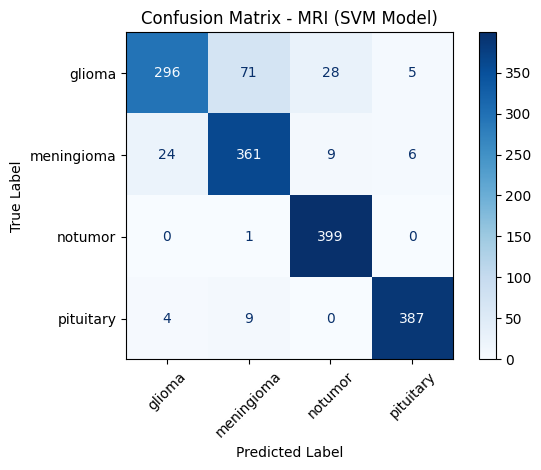

In [36]:
cm_dl_mri = confusion_matrix(y_test_mri, y_pred_ml_mri)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dl_mri,
    display_labels=train_full_mri.classes
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - MRI (SVM Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

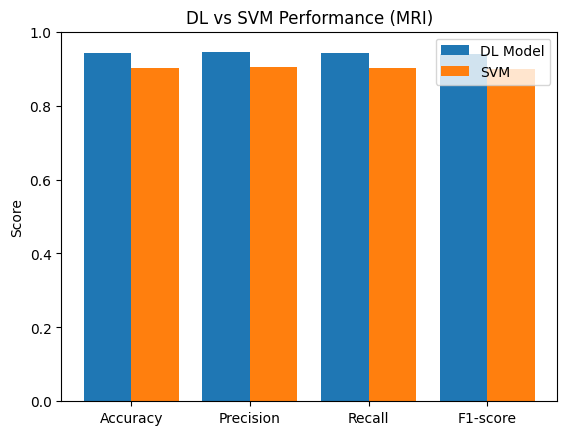

In [37]:
mri_dl_values = [accuracy_dl_mri, precision_dl_mri, recall_dl_mri, f1_dl_mri]
mri_svm_values = [accuracy_svm_mri, precision_svm_mri, recall_svm_mri, f1_svm_mri]

x = range(len(metrics))

plt.figure()

plt.bar(x, mri_dl_values, width=0.4, label='DL Model')
plt.bar([i + 0.4 for i in x], mri_svm_values, width=0.4, label='SVM')

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylim(0, 1)
plt.title("DL vs SVM Performance (MRI)")
plt.ylabel("Score")
plt.legend()

plt.show()

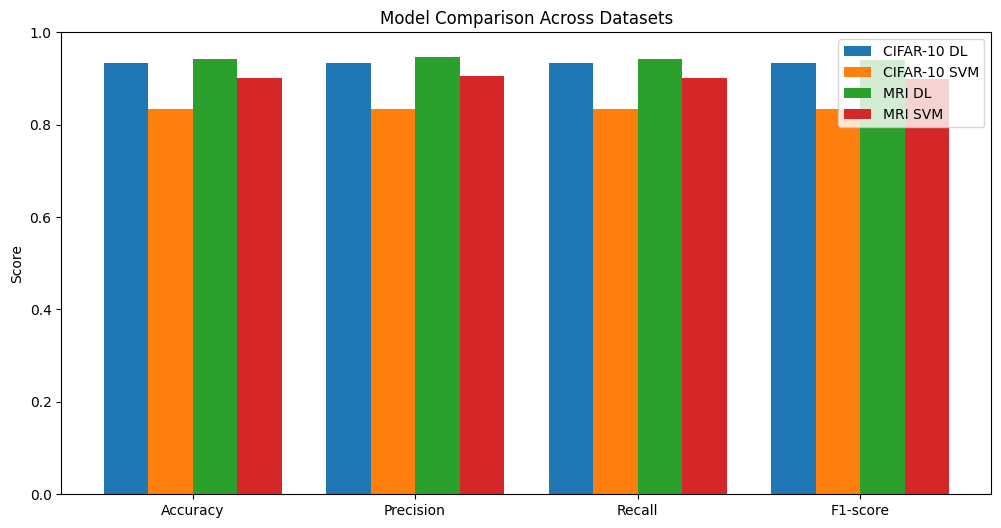

In [38]:
cifar_dl_values = dl_values
cifar_svm_values = svm_values
mri_dl_values = mri_dl_values
mri_svm_values = mri_svm_values

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, cifar_dl_values, width, label='CIFAR-10 DL')
plt.bar(x - 0.5*width, cifar_svm_values, width, label='CIFAR-10 SVM')
plt.bar(x + 0.5*width, mri_dl_values, width, label='MRI DL')
plt.bar(x + 1.5*width, mri_svm_values, width, label='MRI SVM')

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title("Model Comparison Across Datasets")
plt.ylabel("Score")
plt.legend()

plt.show()